# TP n°2 - Krigeage

---

<div style="text-align: right;">
$\text{Julie THOMAS}$

    
<div style="text-align: right;">
$\text{Mathias LOMMEL}$

 
<div style="text-align: right;">
$\textit{5MA - 2024}$

    
---

### Importation des librairies

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import time
from IPython.display import clear_output

## 1°/ Krigeage ordinaire

Dans le cadre du Krigeage simple, on suppose avoir un processus $Z$, issu de paramètres donnés (notés $X$), via une fonction rendant une approche par Monte-Carlo ingérable (les simulations utilisant cette fonction sont très coûteuses). Ainsi, l'objectif est d'approcher ce processus $Z$ en utilisant un certain nombre d'observations $Z_i$, en des points $X_i$ donnés. Ces points $X_1,...X_n$ définissent ce que nous appeleront un "plan d'expérience".

En supposant que nous connaissons nos points $X_i$, nous souhaitons approcher le processus $Z$ par une expression de la forme $\tilde{Z}=\sum_{i=0}^n \lambda_i.Z_i$. 

Dans le cas du Krigeage simple, on supposera que le processus $Z$ est centré ($\mathbb{E}[Z] = 0$, et donc $\mathbb{E}[\tilde{Z}]=0$).

Afin de trouver les valeurs de $\lambda_i$, nous proposons de sélectionner les coefficients qui minimisent la variance de $\tilde{Z} - Z$.

On a :

$$
\begin{align}
\mathbb{V}(\sum_{i=0}^n \lambda_i.Z_i-Z) &= \mathbb{V}(\sum_{i=0}^n \lambda_i.Z_i) + \mathbb{V}(Z) - 2.Cov(\sum_{i=0}^n \lambda_i.Z_i,Z)\\
&= \mathbb{V}(Z) + Cov(\sum_{i=0}^n \lambda_i.Z_i,\sum_{j=0}^n \lambda_j.Z_j) - 2.\sum_{i=0}^n \lambda_i.Cov(Z_i,Z) \\
&= \mathbb{V}(Z) + \sum_{i=0}^n \sum_{j=0}^n \lambda_i.\lambda_j.Cov(Z_i, Z_j) - 2.\sum_{i=0}^n \lambda_i.Cov(Z_i,Z) 
\end{align}
$$

Nous souhaitons déterminer le minimum de cette expression. Nous allons donc dériver cette variance par rapport à $\lambda_i$, $\forall i \in \left\{0,...,n \right\}$.

Dérivée première de la variance :$\frac{\partial \mathbb{V}}{\partial \lambda_i} = 2.\sum_{j=0}^n \lambda_j.Cov(Z_i, Z_j) -2.Cov(Z_i,Z)$.

Dérivée seconde de la variance : $\frac{\partial^2 \mathbb{V}}{\partial \lambda_i^2} = 2.Cov(Z_i, Z_i) = 2.\mathbb{V}(Z_i) \ge 0$.

La dérivée seconde étant positive, nous trouverons bel et bien un minimum en annulant la dérivée première. En écrivant la condition de nullité pour tout $i \in \left\{0,...,n\right\}$, on obtient : 

$$
\left\{
\begin{align}
\sum_{j=0}^n \lambda_j.Cov(Z_0, Z_j) &= Cov(Z_0,Z) \\
\sum_{j=0}^n \lambda_j.Cov(Z_1, Z_j) &= Cov(Z_1,Z) \\
&\vdots \\
\sum_{j=0}^n \lambda_j.Cov(Z_n, Z_j) &= Cov(Z_n,Z) \\
\end{align}
\right.
\iff \begin{pmatrix}
\mathbb{V}(Z_0) & Cov(Z_0,Z_2) & \cdots & Cov(Z_0,Z_n) \\
Cov(Z_1,Z_0) & \mathbb{V}(Z_1) & \cdots & Cov(Z_1,Z_n) \\
\vdots & \ddots & \vdots \\
Cov(Z_n,Z_0) & Cov(Z_n,Z_1) & \cdots & \mathbb{V}(Z_n) 
\end{pmatrix}.\begin{pmatrix} \lambda_0 \\ \lambda_1 \\ \vdots \\ \lambda_n \end{pmatrix} = \begin{pmatrix} Cov(Z_0,Z) \\ Cov(Z_1,Z) \\ \vdots \\ Cov(Z_n,Z) \end{pmatrix}
\iff K.\Lambda = k_0
$$

Nous obtenons donc une équation matricielle. Celle-ci, sous l'hypothèse de l'inversibilité de la matrice $K$, nous donne finalement les valeurs optimales pour les coefiicients recherchés. 

Les coefficients $\lambda_1,...,\lambda_n$ minimisant la variance $\mathbb{V}(\sum_{i=0}^n \lambda_i.Z_i-Z)$ sont : 
$$
\tilde{\lambda} = K^{-1}.k_0 = \begin{pmatrix}
\mathbb{V}(Z_0) & Cov(Z_0,Z_1) & \cdots & Cov(Z_0,Z_n) \\
Cov(Z_1,Z_0) & \mathbb{V}(Z_1) & \cdots & Cov(Z_1,Z_n) \\
\vdots & \ddots & \vdots \\
Cov(Z_n,Z_0) & Cov(Z_n,Z_1) & \cdots & \mathbb{V}(Z_n) 
\end{pmatrix}^{-1}.\begin{pmatrix} Cov(Z_0,Z) \\ Cov(Z_1,Z) \\ \vdots \\ Cov(Z_n,Z) \end{pmatrix}
$$


## 2°/ Mise en oeuvre du krigeage simple sur un cas 1D

Dans cette seconde partie, nous allons appliquer les équations du Krigeage simple sur un cas à une dimension.

### Données du cas d'étude

In [3]:
# Proposition des deux plans d'expériences
pXp1 = np.array([-1.8,-1.4,-1.0,-0.6,-0.2,0.2,0.6,1.0,1.4,1.8])
pXp2 = np.array([-1.76, -1.33, -1.00, -0.61, -0.22, 0.26, 0.580, 1.05, 1.47, 1.78,1.75952747,-0.64195440,-0.83923903,-1.35499968,-0.99752380,-1.60945922])

# Définition de la fonction d'étude
def f(x):
    y = np.exp(-(x*25+40)**2/350)*20-np.exp(-(x*25-10)**2/50)*5+np.sin((x*25+50)/80)*25-19
    return y
# Et de son noyau de covariance
def covar(h):
    return 25*np.exp(-(h)**2/(0.22))

### Mise en place du Krigeage

#### 1 - Création d'une grille d'abscisse, et affichage de la fonction f

Tout d'abord, nous pouvons commencer par afficher la fonction d'intérêt sur l'intervalle [-2,2], accompagné des 2 plans d'expérience proposés.

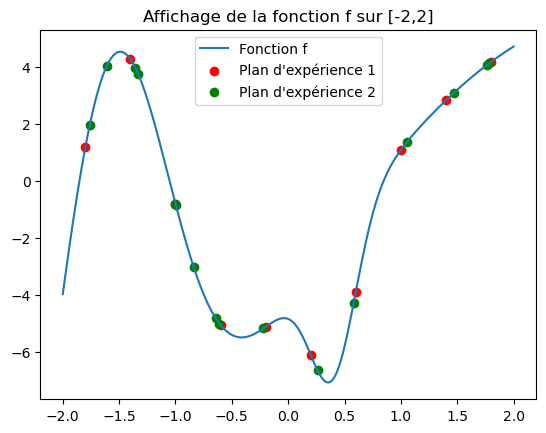

In [4]:
# Grille d'abscisses
grille_x = np.linspace(-2,2,400)
# Calcul de la fonctions aux points du plan d'expérience
Z1 = f(pXp1)
Z2 = f(pXp2)
# Affichage graphique
plt.plot(grille_x,f(grille_x),label="Fonction f")
plt.scatter(pXp1,Z1,color="red",label="Plan d'expérience 1")
plt.scatter(pXp2,Z2,color="green",label="Plan d'expérience 2")
plt.title("Affichage de la fonction f sur [-2,2]")
plt.legend()

#### 2 - Création des fonctions de covariance

Désormais, nous voudrions réaliser une prédiction de la fonction f, en un certain point $x$, par $Krigeage~simple$. Pour cela, nous nous baserons sur les équations que nous avons établies précédemment.

Nous construirons deux fonctions, l'une déterminant la matrice de covariance du processus, en des points X donnés, et l'autre calculant la covariance entre le processus aux points de X, et un point donné $x_0$. Elles seront notées ``matrice_covar``, et ``vecteur_covar`` respectivement. 

Pour cela, nous utiliserons la propriété selon laquelle $Z$ est à accroissements stationnaires, ce qui signifie que $Cov(Z(x_1),Z(x_2))$ ne dépend que de l'écart $x_1 - x_2$.

In [5]:
def matrice_covar(X):
    """
    Fonction calculant la matrice de covariance du processus Z1,...,Zn, correspondant aux positions X1,...,Xn
    
    Entrée : 
        - X : Array - Positions du processus
    
    Sortie : 
        - cov : Array - Matrice de covariances
    """
    # Nombre de positions
    n = len(X)
    # Initialisation de la matrice
    cov = np.ones((n,n))
    # Remplissage itératif de la matrice
    for i in range(n):
        cov[i,:] = X - X[i]
    # Application de la fonction de covariance
    cov = covar(cov)
    
    return cov

In [6]:
def vecteur_covar(X,x0):
    """
    Fonction calculant la covariance entre Z1,...,Zn, et Z(x0), avec x0 donné
    
    Entrée : 
        - X  : Array - Positions du processus
        - x0 : Array - Position du point de référence
    
    Sortie : 
        - vect : Array - Vecteur des covariances
    """
    # Calcul de la covariance
    vect = covar(X-x0)
    
    return vect

#### 3 - Prédictions avec le plan d'expérience n°1

Désormais, nous pouvons utiliser ces fonctions pour réaliser une prédiction de la fonction f à l'origine $x_0=0$.

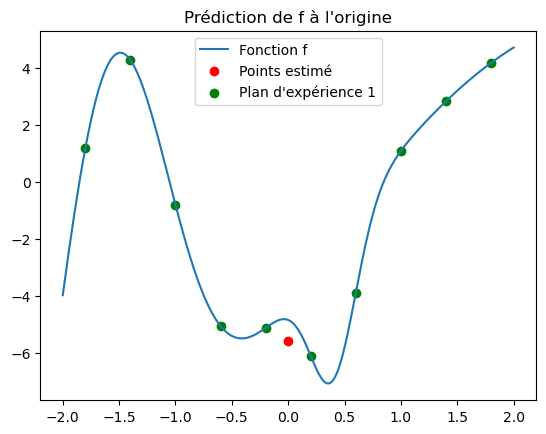

In [7]:
# Point d'intérêt
x0 = 0
# Matrice de covariances
K = matrice_covar(pXp1)
# Vecteur des covariances
k0 = vecteur_covar(pXp1,x0)
# Calcul des valeurs otpimales de lambda
l1 = np.linalg.inv(K)@k0

# Estimation de la fonction en x0
y_hat_1 = np.sum(l1*f(pXp1))

plt.plot(grille_x,f(grille_x),label="Fonction f")
plt.scatter(x0,y_hat_1,color="red",label="Points estimé")
plt.scatter(pXp1,Z1,color="green",label="Plan d'expérience 1")
plt.title("Prédiction de f à l'origine")
plt.legend()

Comme nous pouvons le voir, la valeur prédite n'est pas tout à fait sur la courbe représentant la fonction, mais semble être sur la droite reliant les deux points du plan d'expérience qui encadrent la valeur $x_0=0$. Dans la suite, nous souhaiterions réaliser cette prédiction sur plusieurs points, afin d'obtenir une approximation de la fonction f.

#### 4 - Prédictions multiples

COmme indiqué ci-dessus, nous pouvons réaliser le même travail en faisant varier la position de $x_0$.

In [8]:
# Initialisation du vecteur de prédiction
y_hat = []
# Remplissage des prédictions
for x0 in grille_x:
    # Matrice et vecteur de covariance
    K = matrice_covar(pXp1)
    k0 = vecteur_covar(pXp1,x0)
    # Calcul des valeurs pour lambda
    l2 = np.linalg.inv(K)@k0
    # Prédiction de la fonction en x0
    y_hat.append(np.sum(l2*f(pXp1)))

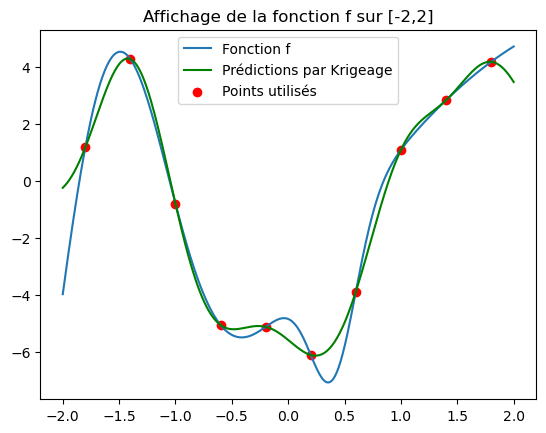

In [9]:
# Affichage du résultat
plt.plot(grille_x,f(grille_x),label="Fonction f")
plt.plot(grille_x,y_hat,color="green",label="Prédictions par Krigeage")
plt.scatter(pXp1,Z1,color="red",label="Points utilisés")
plt.title("Affichage de la fonction f sur [-2,2]")
plt.legend()

On observe que la prédiction semble assez proche de la valeur réelle de la fonction. Toutefois, en certains points, l'écart à la réalité semble être plus grand que dans d'autres cas.

Ainsi, nous souhaiterions connaître la qualité de la prédiction réalisée en chaque point de la discrétisation de la fonction. Pour cela, nous allons utiliser l'estimation de la variance en ces points, afin de construire une "zone de confiance". Cette zone sera considérée comme étant $[\widehat{y} - 2.\widehat\sigma, \widehat{y} + 2.\widehat\sigma]$.

Pour cela, nous devons d'abord déterminer l'expression analytique de la variance. Comme nous avons pu le voir précédemment, la variance de l'erreur $\epsilon_{x} = \tilde{Z}(x) - Z(x)$ est donnée par :
$$
\mathbb{V}(\epsilon) = \mathbb{V}(\sum_{i=0}^n \lambda_i.Z_i-Z) = \mathbb{V}(Z) + \sum_{i=0}^n \sum_{j=0}^n \lambda_i.\lambda_j.Cov(Z_i, Z_j) - 2.\sum_{i=0}^n \lambda_i.Cov(Z_i,Z) 
$$

Or, d'après les équations du Krigeage, nous avons : $\forall i \in \left\{0,...,n\right\}, \sum_{j=0}^n \lambda_j.Cov(Z_i, Z_j) = Cov(Z_i,Z)$.

D'où :
$$
\begin{align}
\mathbb{V}(\epsilon) 
&= \mathbb{V}(Z) + \sum_{i=0}^n \sum_{j=0}^n \lambda_i.\lambda_j.Cov(Z_i, Z_j) - 2.\sum_{i=0}^n \lambda_i.Cov(Z_i,Z) \\
&= \mathbb{V}(Z) + \sum_{i=0}^n \lambda_i.\left( \sum_{j=0}^n \lambda_j.Cov(Z_i, Z_j) \right) - 2.\sum_{i=0}^n \lambda_i.Cov(Z_i,Z) \\
&= \mathbb{V}(Z) + \sum_{i=0}^n \lambda_i.\left( Cov(Z_i, Z) \right) - 2.\sum_{i=0}^n \lambda_i.Cov(Z_i,Z) \\
&= \mathbb{V}(Z) - \sum_{i=0}^n \lambda_i.Cov(Z_i, Z) \\
&= \mathbb{V}(Z) - \sum_{i=0}^n (K^{-1}.k_0)_i.(k_0)_i \\
&= \sigma^2 - (K^{-1}.k_0)^T.k_0 =  \sigma^2 - k_0^T.K^{-1}.k_0  \\
\end{align}
$$

On obtient finalement : $\widehat \sigma = \sqrt{covar(0) - k_0^T.K^{-1}.k_0}$.

#### 5 - Ajout de la variance pour visualiser la qualité de prédiction

Pour ajouter la "zone de confiance" dans l'affichage de nos prédictions, nous allons construire 2 nouvelles fonctions : 
- ```compute_pred``` : qui réalise les prédictions de la fonction f sur les points d'un grille "grille_x" donnée, à partir d'un plan d'expérience "pXp", et de la valeur de la fonction en ces points "Z"
- ```display_pred``` : qui affiche le graphique de cette prédiction, accompagné de la qualité d'ajustement

In [10]:
def compute_pred(grille_x, pXp,Z):
    """
    Fonction réalisant les prédictions de f sur la grille donnée
    
    Entrées : 
        - grille_x  : Array - Positions du processus à prédire
        - pXp       : Array - Plan d'expérience considéré
        - Z         : Array - Valeurs du processus sur le plan d'expérience
    
    Sorties : 
        - y_hat : Array - Vecteur des prédictions
        - s     : Array - Variance estimée de la prédiction
    """
    # Initialisation des vecteurs de sortie
    y_hat = []
    s = []
    # Pour chaque point de la grille de discrétisation
    for x0 in grille_x:
        # Calcul des données nécessaires à la prédiction
        K = matrice_covar(pXp)
        k0 = vecteur_covar(pXp,x0)
        
        # Calcul de la prédiction, et ajout à la liste
        l2 = np.linalg.inv(K)@k0
        y_hat.append(np.sum(l2*Z))
        # Calcul de l'écart-type et ajout à la liste
        sigma = covar(0) - np.transpose(k0)@np.linalg.inv(K)@k0 
        sigma = sigma*(sigma>0)
        s.append(np.sqrt(sigma))
    # On renvoie les prédictions et leur variance
    return y_hat, s

In [11]:
def display_pred(grille_x,pXp,Z):
    """
    Fonction affichant la prédiction réalisée, accompagnée de sa "région de confiance"
    
    Entrées : 
        - grille_x  : Array - Positions du processus à prédire
        - pXp       : Array - Plan d'expérience considéré
        - Z         : Array - Valeurs du processus sur le plan d'expérience
    """
    # Réalisation des prédictions
    y_hat, s = compute_pred(grille_x, pXp,Z)
    # Affichage de la fonction exacte
    plt.plot(grille_x, f(grille_x), label="Fonction f")
    # Affichage des prédictions réalisées
    plt.plot(grille_x, y_hat, color="green", label="Prédictions par Krigeage")

    # Création de la bande de confiance
    plt.fill_between(grille_x, 
                     [y_hat[i] - 2 * s[i] for i in range(len(s))], 
                     [y_hat[i] + 2 * s[i] for i in range(len(s))],
                     color="grey", alpha=0.3,label="Variance de la prédiction")  # alpha pour la transparence

    # Ajout des points du plan d'expérience
    plt.scatter(pXp, Z, color="red", label="Points utilisés")

    # Ajout du titre et de la légende
    plt.title("Application du Krigeage à la fonction f")
    plt.legend()

##### $\to$ Application au Plan d'expérience n°1

Nous pouvons désormais tester ces deux fonctions avec le plan d'expérience n°1.

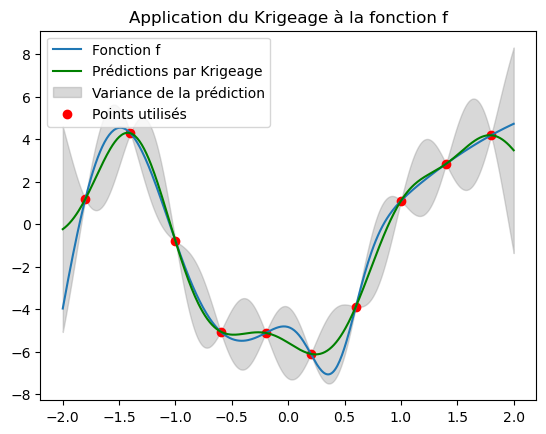

In [12]:
display_pred(grille_x,pXp1,Z1)

Comme nous avions pu le voir en cours, nous visualisons les zones de confiances que nous souhaitions observer. En effet, en chacun des points, la variance de la prédiction est nulle, puisque nous connaissons la valeur vraie du processus, et dès lors que l'on s'éloigne de ces points, la variance augmente, ce qui conduit à une zone de confiance plus large.

##### $\to$ Application au Plan d'expérience n°2

De la même manière, nous pouvons appliquer les fonctions sur le second plan d'expérience. Celui-ci étant composé d'un nombre plus grand de points, nous nous attendons à obtenir de meilleures prédictions (i.e. avec une variance plus petite).

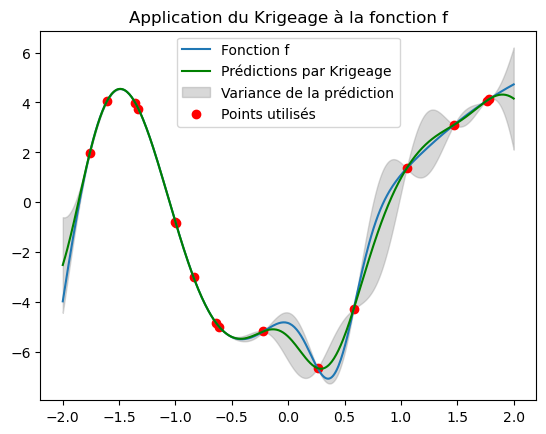

In [13]:
display_pred(grille_x,pXp2,Z2)

Comme prévu, on observe une variance plus faible que pour le plan d'expérience précédent, notamment sur la partie gauche de la grille, où la variance est presque nulle en tout point. Bien entendu, cette diminution de la variance s'est faite au détriment du coût de calcul, qui est ici théoriquement 1.6x supérieur (1.6 fois plus de points dans ce second plan d'expérience).

In [14]:
_, sigma_pXp1 = compute_pred(grille_x, pXp1,f(pXp1))
_, sigma_pXp2 = compute_pred(grille_x, pXp2,f(pXp2))

print("Plan d'expérience n°1 :")
print("  - Nombre de points : ",len(pXp1))
print("  - Variance cumulée : ",np.round(np.sum(sigma_pXp1),3))
print("")
print("Plan d'expérience n°2 :")
print("  - Nombre de points : ",len(pXp2)," (+",np.round((len(pXp2)/len(pXp1) - 1)*100,2),"%)")
print("  - Variance cumulée : ",np.round(np.sum(sigma_pXp2),3)," (-",np.round(abs(1-np.sum(sigma_pXp2)/np.sum(sigma_pXp1))*100,3),"%)")

Plan d'expérience n°1 :
  - Nombre de points :  10
  - Variance cumulée :  255.051

Plan d'expérience n°2 :
  - Nombre de points :  16  (+ 60.0 %)
  - Variance cumulée :  89.735  (- 64.817 %)


On observe toutefois que l'augmentation du coût de calcul permet une diminution de la variance cumulée proportionnellement similaire.

### Proposition d'un autre plan d'expérience

Dans cette dernière partie, on se propose d'établir intelligemment un nouveau plan d'expérience. 

L'idée est la suivante : partir d'un certain nombre de points initiaux, puis, itérativement, appliquer les prédictions avec les points choisis, et ajouter un point là où la variance est maximale. 

Nous définirons un nombre de point maximal, correspondant à notre budget de calcul maximal. En itérant de cette manière, nous pourrons obtenir un nouveau plan d'expérience, avec un nombre de points donné (et donc un budget de calcul donné).

Pour faire cela, nous allons construire 2 fonctions :
- ```compute_x_nb_pt``` : qui détermine le nouveau plan d'expérience suivant l'heuristique présentée, et avec un critère d'arrêt de la recherche associé au nombre de points du plan
- ```display_heuristic``` : qui affiche la dynamique de recherche de ce plan d'expérience

In [15]:
def compute_x_nb_pt(p,nb_max):
    """
    Détermine un nouveau plan d'expérience, à partir de points initiaux, et avec un nombre de points maximal.

    Entrées :
        - p      : Array NumPy - Points initiaux
        - nb_max : Integer     - Nombre de points maximal

    Sortie : 
        - historic : Array - Historique des points, des valeurs de f en ces points, des prédictions et de la variance
    """
    nb_pt = len(p)
    # Application des prédictions
    Z = f(p)
    y_hat, sigma = compute_pred(grille_x, p, Z)

    # Création de l'historique des prédictions
    historic = [[p,Z,y_hat,sigma]]

    # Tant que notre plan d'expérience n'est pas de la même taille que pXp1
    while (nb_pt < nb_max):
        # Identification du nouveau point
        id_new_x = np.where(sigma == np.max(sigma))[0][0]
        new_x = grille_x[id_new_x]

        # Ajout du point au plan d'expérience
        p = np.append(p,new_x)
        p = np.sort(p)
        nb_pt = nb_pt + 1

        # Réalisation de la prédiction
        Z = f(p)
        y_hat, sigma = compute_pred(grille_x, p, Z)

        historic.append([p,Z,y_hat,sigma])
    
    return historic

In [16]:
def display_heuristic(historic):
    """
    Affiche de manière dynamique la variation du plan d'expérience dans l'heuristique présentée précédemment.

    Entrée : 
        - historic : Array - Vecteur de sortie de la fonction précédente
    """
    # Pour chaque itération de l'algorithme
    for vect in historic:
        # On supprime le plot précédent
        clear_output(wait=True)
        # Récupération des données de l'historique
        pXp = vect[0]
        Z = vect[1]
        y_hat = vect[2]
        s = vect[3]
        nb_pt = len(pXp)
        # Affichage de la fonction exacte
        plt.plot(grille_x, f(grille_x), label="Fonction f")
        # Affichage des prédictions à l'itération donnée
        plt.plot(grille_x, y_hat, color="green", label="Prédictions par Krigeage")

        # Ajout des bandes de confiance
        plt.fill_between(grille_x, 
                         [y_hat[i] - 2 * s[i] for i in range(len(s))], 
                         [y_hat[i] + 2 * s[i] for i in range(len(s))],
                         color="grey", alpha=0.3,label="Variance de la prédiction")  # alpha pour la transparence

        # Ajout du plan d'expérience de l'itération concernée
        plt.scatter(pXp, Z, color="red", label="Points utilisés")

        # Ajout du titre et de la légende
        plt.title(f"Krigeage, avec {nb_pt} points")
        plt.legend()
        plt.show()
        # Pour la dynamique, on attend 0.3s avant de passer à l'affichage de l'itération suivante
        time.sleep(0.3)

#### $\to$ Application au Plan d'expérience n°1

Désormais, nous pouvons appliquer ces deux fonctions pour déterminer un plan d'expérience ayant le même coût que le plan d'expérience pXp1, et ce en partant de 2 points (extrémités de l'intervalle d'étude).

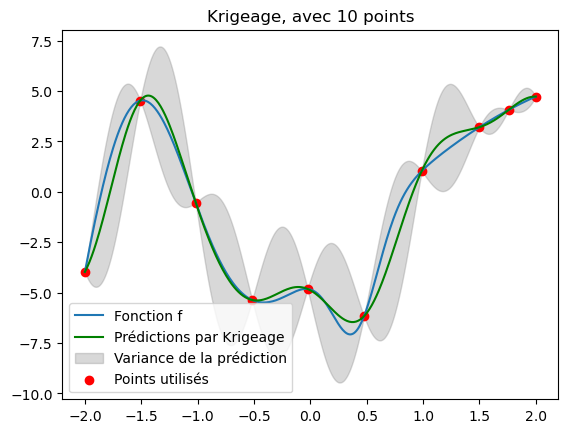

In [17]:
# Initialisation de notre plan d'expérience
p = np.array([-2,2])
# On souhaite avoir le même coût de calcul que le plan d'expérience n°1
nb_max = len(pXp1)
# Détermination de l'historique
historic_1 = compute_x_nb_pt(p,nb_max)
# Affichage de la dynamique
display_heuristic(historic_1)

Nous obtenons finalement un nouveau plan d'expérience. 

Pour pouvoir comparer qualitativement et quantitativement ce nouveau plan face au plan d'expérience n°1, nous proposons de construire 2 fonctions : 
- ```var_comparison``` : qui résume les propriétés de la variance des prédictions réalisées dans les deux cas
- ```compare``` : qui compare qualitativement les deux prédictions, en superposant celles-ci sur un même graphe

In [50]:
def var_summary(sigma,label):
    print("Avec ",label," : ")
    print(" - moyenne : ",np.mean(sigma))
    print(" - minimum : ",np.min(sigma))
    print(" - maximum : ",np.max(sigma))
    print(" - Variance totale (somme) : ",np.sum(sigma))
    print("\n")
    
def var_comparison(pXp,historic,label_historic, label_pXp):
    """
    Fonction de comparaison de la variance de deux prédictions.
    
    Entrées : 
        - historic       : Array  - Historique associé au plan d'expérience heuristique
        - pXp            : Array  - Plan d'expérience de comparaison
        - label_historic : String - Qualificatif pour le plan d'expérience de l'historique
        - label_pXp      : String - Qualificatif pour le plan d'expérience de comparaison
    
    """
    # Récupération des variances pour les deux plans
    sigma_f = historic[-1][3]
    _, sigma_pXp = compute_pred(grille_x, pXp,f(pXp))
    
    # Résumé de leur variance
    var_summary(sigma_pXp,label_pXp)
    var_summary(sigma_f,label_historic)
    
    # Affichage de leur boxplot
    plt.boxplot([sigma_pXp], 
                positions=[1],  # Positionner les boxplots l'un à côté de l'autre
                widths=0.5,  # Largeur des boxplots
                patch_artist=True,  # Remplir avec des couleurs
                boxprops=dict(facecolor='orange', color='orange'),  # Couleur du premier boxplot
                whiskerprops=dict(color='orange'),  # Couleur des moustaches du premier boxplot
                flierprops=dict(markerfacecolor='orange', marker='o', color='orange')  # Couleur des points aberrants du premier boxplot
    )

    plt.boxplot([sigma_f], 
                positions=[2],  # Positionner le boxplot du second plan
                widths=0.5,  # Largeur des boxplots
                patch_artist=True,  # Remplir avec des couleurs
                boxprops=dict(facecolor='green', color='green'),  # Couleur du second boxplot
                whiskerprops=dict(color='green'),  # Couleur des moustaches du second boxplot
                flierprops=dict(markerfacecolor='green', marker='o', color='green')  # Couleur des points aberrants du second boxplot
    )

    # Ajout de la légende
    plt.legend([label_pXp, label_historic], loc="upper right")

    # Affichage du graphique
    plt.show()

In [51]:
def compare(p_1,p_2,label_1,label_2):
    """
    Fonction de comparaison des prédictions faites avec 2 plans d'expérience différents.

    Entrées : 
        - p_1 : Array - Plan d'expérience n°1
        - p_2 : Array - Plan d'expérience n°2
    """

    # Valeurs de la fonction aux points des plans 1 et 2
    Z_1 = f(p_1)
    Z_2 = f(p_2)
    # Réalisation des prédictions pour les deux plans
    y_hat_1, s_1 = compute_pred(grille_x, p_1,Z_1)
    y_hat_2, s_2 = compute_pred(grille_x, p_2,Z_2)

    # Affichage de la fonction exacte
    plt.plot(grille_x, f(grille_x), color="blue", label="Fonction f")
    
    ################################
    ## Affichage pour le plan n°1 ##
    ################################
    # Affichage des prédictions
    plt.plot(grille_x, y_hat_1, color="orange", label=label_1)
    # Zones de confiance des prédictions
    plt.fill_between(grille_x, 
                     [y_hat_1[i] - 2 * s_1[i] for i in range(len(s_1))], 
                     [y_hat_1[i] + 2 * s_1[i] for i in range(len(s_1))],
                     color="orange", alpha=0.2)
    # Ajout des points du plan d'expérience 
    plt.scatter(p_1, Z_1, color="orange")

    ################################
    ## Affichage pour le plan n°2 ##
    ################################
    # Affichage des prédictions
    plt.plot(grille_x, y_hat_2, color="green", label=label_2)
    # Zones de confiance des prédictions
    plt.fill_between(grille_x, 
                     [y_hat_2[i] - 2 * s_2[i] for i in range(len(s_2))], 
                     [y_hat_2[i] + 2 * s_2[i] for i in range(len(s_2))],
                     color="green", alpha=0.2)  # alpha pour la transparence
    # Ajout des points du plan d'expérience
    plt.scatter(p_2, Z_2, color="green")

    # Ajout du titre et de la légende
    plt.title("Comparaison des résultats")
    plt.legend()
    # Affichage du graphique
    plt.show()

Nous pouvons appliquer ces fonctions dans notre cas d'étude. 

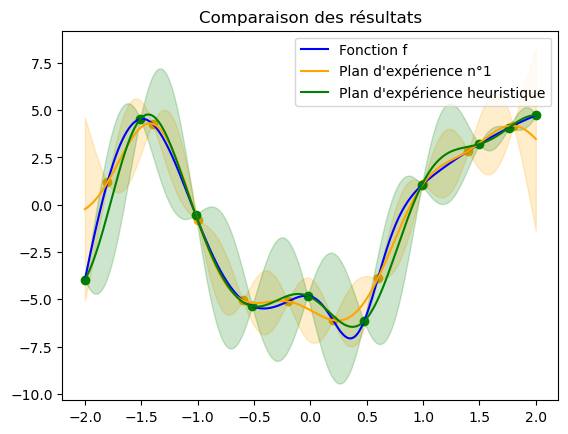

In [52]:
compare(pXp1,historic_1[-1][0],"Plan d'expérience n°1","Plan d'expérience heuristique")

Comme nous pouvons le voir, en démarrant notre plan d'expérience avec les bords du domaine, nous diminuons drastiquement la variance aux bords de l'intervalle. Toutefois, il semblerait que la variance soit plus grande sur le reste du domaine : le nouveau plan d'expérience semble être moins bon que celui donné.

Pour quantifier la différence, nous allons comparer les propriétés des variances obtenues dans les deux cas, en utilisant la fonction présentée ci-dessus.

Avec  plan n°1  : 
 - moyenne :  0.6376283131659295
 - minimum :  0.005203077885715292
 - maximum :  2.419193951871254
 - Variance totale (somme) :  255.05132526637178


Avec  plan heuristique  : 
 - moyenne :  0.9152625965137575
 - minimum :  -0.0
 - maximum :  1.7163669150392575
 - Variance totale (somme) :  366.105038605503




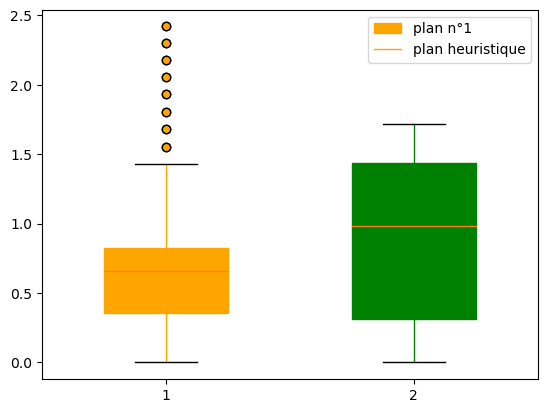

Plan d'expérience n°1 :
  - Nombre de points :  10
  - Variance cumulée :  255.051

Plan d'expérience heuristique :
  - Nombre de points :  10  (+ 0.0 %)
  - Variance cumulée :  366.105  (+ 43.542 %)


In [53]:
var_comparison(pXp1,historic_1,"plan heuristique", "plan n°1")

sigma_f = historic_1[-1][3]

print("Plan d'expérience n°1 :")
print("  - Nombre de points : ",len(pXp1))
print("  - Variance cumulée : ",np.round(np.sum(sigma_pXp1),3))
print("")
print("Plan d'expérience heuristique :")
print("  - Nombre de points : ",len(historic_1[-1][0])," (+",np.round((len(historic_1[-1][0])/len(pXp1) - 1)*100,2),"%)")
print("  - Variance cumulée : ",np.round(np.sum(sigma_f),3)," (+",np.round(abs(np.sum(sigma_f)/np.sum(sigma_pXp1)-1)*100,3),"%)")

Comme nous l'avions imaginé précédemment, la variance des prédictions faites avec notre plan heuristique est en effet, en moyenne plus grande. La somme des variance (variance cumulée) est elle aussi supérieure, bien que la variance maximale soit bien plus petite que celle obtenue avec le plan n°1 (ceci est certainement lié au fait d'avoir choisi les points initiaux aux extrémités du domaine).

#### Proposition d'un autre critère d'arrêt

Nous allons désormais considérer que nous souhaitons obtenir un plan d'expérience meilleur que le plan n°1. Dans cette partie, nous allons donc chercher un plan d'expérience ayant une variance cumulée plus petite que la variance cumulée obtenue avec le plan n°1 : nous aurons un nouveau critère d'arrêt pour notre recherche heuristique. 

Pour conduire ces changements, nous allons construire une nouvelle fonction, égale en tout point à ```compute_x_nb_pt```, avec un critère d'arrêt différent. *Voir ```compute_x_var```*.

In [54]:
def compute_x_var(p,var_max):
    """
    Détermine un nouveau plan d'expérience, à partir de points initiaux, et avec une variance cumulée maximale.

    Entrées :
        - p       : Array NumPy - Points initiaux
        - var_max : Integer     - Variance cumulée maximale

    Sortie : 
        - historic : Array - Historique des points, des valeurs de f en ces points, des prédictions et de la variance
    """
    nb_pt = len(p)
    # Application des prédictions
    Z = f(p)
    y_hat, sigma = compute_pred(grille_x, p, Z)

    # Création de l'historique des prédictions
    historic = [[p,Z,y_hat,sigma,nb_pt]]

    # Tant que notre plan d'expérience n'a pas une variance cumulée plus petite que la limite
    while (np.sum(sigma) > var_max):
        # Identification du nouveau point
        id_new_x = np.where(sigma == np.max(sigma))[0][0]
        new_x = grille_x[id_new_x]

        # Ajout du point au plan d'expérience
        p = np.append(p,new_x)
        p = np.sort(p)
        nb_pt = nb_pt + 1

        # Réalisation de la prédiction
        Z = f(p)
        y_hat, sigma = compute_pred(grille_x, p, Z)

        historic.append([p,Z,y_hat,sigma,nb_pt])
    
    return historic

##### $\to$ Application au Plan d'expérience n°1

In [55]:
# Initialisation de notre plan d'expérience
p = np.array([-2,2])
var_max = np.sum(sigma_pXp1)

historic_2 = compute_x_var(p,var_max)

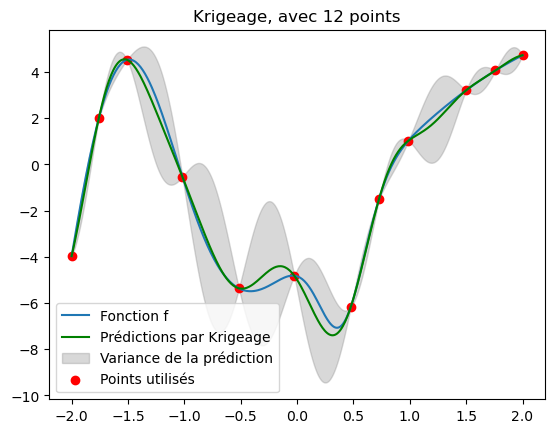

In [56]:
display_heuristic(historic_2)

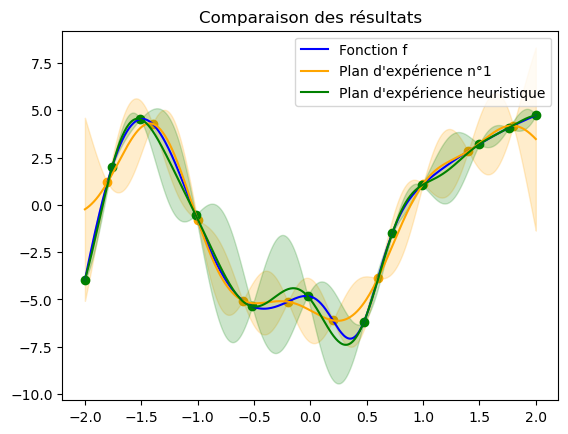

In [57]:
compare(pXp1,historic_2[-1][0],"Plan d'expérience n°1","Plan d'expérience heuristique")

Avec  plan n°1  : 
 - moyenne :  0.6376283131659295
 - minimum :  0.005203077885715292
 - maximum :  2.419193951871254
 - Variance totale (somme) :  255.05132526637178


Avec  plan heuristique  : 
 - moyenne :  0.549126451618775
 - minimum :  -0.0
 - maximum :  1.5764563042189144
 - Variance totale (somme) :  219.65058064751003




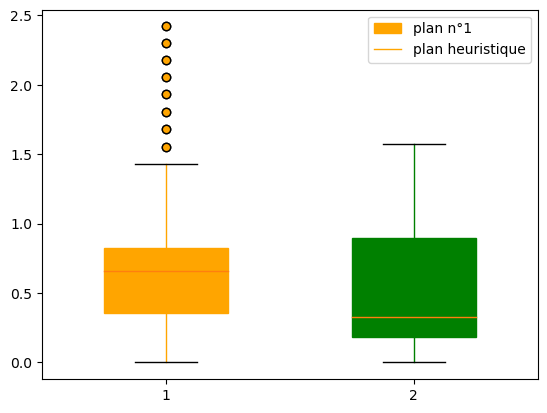

Plan d'expérience n°1 :
  - Nombre de points :  10
  - Variance cumulée :  255.051

Plan d'expérience heuristique :
  - Nombre de points :  12  (+ 20.0 %)
  - Variance cumulée :  219.651  (- 13.88 %)


In [58]:
var_comparison(pXp1,historic_2,"plan heuristique", "plan n°1")

sigma_f = historic_2[-1][3]

print("Plan d'expérience n°1 :")
print("  - Nombre de points : ",len(pXp1))
print("  - Variance cumulée : ",np.round(np.sum(sigma_pXp1),3))
print("")
print("Plan d'expérience heuristique :")
print("  - Nombre de points : ",len(historic_2[-1][0])," (+",np.round((len(historic_2[-1][0])/len(pXp1) - 1)*100,2),"%)")
print("  - Variance cumulée : ",np.round(np.sum(sigma_f),3)," (-",np.round(abs(np.sum(sigma_f)/np.sum(sigma_pXp1)-1)*100,3),"%)")

Comme nous pouvons le voir, nous avons désormais une variance cumulée plus petite, de moyenne et de valeur maximale plus petite. La qualité de la prédiction s'est ici faite au détriment du coût de calcul. 

Nous remarquons d'ailleurs que le coût de calcul est proportionnellement plus important que le gain de variance qu'il permet.

##### $\to$Application au plan d'expérience n°2

Désormais, nous souhaiterions réaliser la mêmes comparaisons, mais cette fois avec le plan d'expérience n°2 proposé. L'idée ici étant de savoir si, pour ce nouveau budget de calcul, il est possible de trouver un meilleur plan d'expérience, et s'il est éventuellement possible de faire aussi bien, avec un coût de calcul plus petit.

In [59]:
# Initialisation de notre plan d'expérience
p = np.array([-2,2])
nb_max = len(pXp2)

historic_3 = compute_x_nb_pt(p,nb_max)

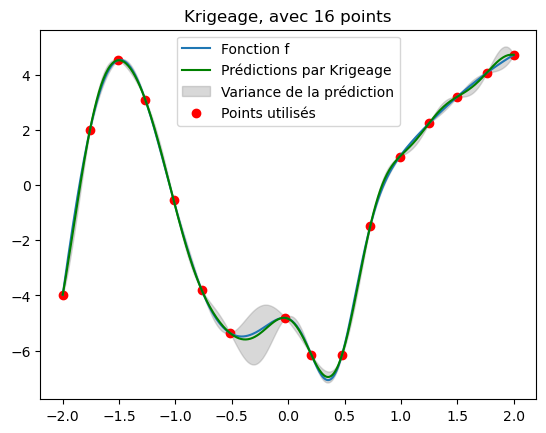

In [60]:
display_heuristic(historic_3)

Comme nous pouvons le voir, avec 16 points, nous obtenons une variance très faible, et proche de 0 presque sur tout le domaine d'étude [-2,2]. Nous pouvons d'ailleurs quantifier cette qualité d'ajustement.

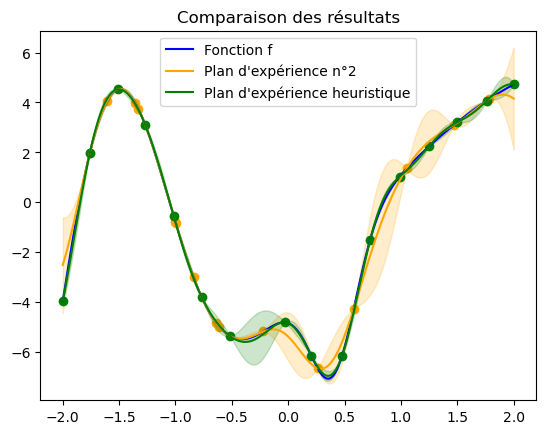

In [61]:
compare(pXp2,historic_3[-1][0],"Plan d'expérience n°2","Plan d'expérience heuristique")

Avec  plan n°1  : 
 - moyenne :  0.2243381110162369
 - minimum :  -0.0
 - maximum :  1.0236716641560124
 - Variance totale (somme) :  89.73524440649476


Avec  plan heuristique  : 
 - moyenne :  0.09498684526626851
 - minimum :  -0.0
 - maximum :  0.5053814645584151
 - Variance totale (somme) :  37.994738106507405




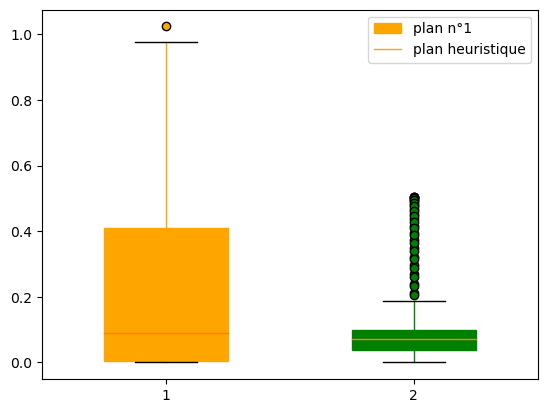

Plan d'expérience n°1 :
  - Nombre de points :  16
  - Variance cumulée :  89.735

Plan d'expérience heuristique :
  - Nombre de points :  16  (+ 0.0 %)
  - Variance cumulée :  37.995  (- 57.659 %)


In [62]:
var_comparison(pXp2,historic_3,"plan heuristique", "plan n°1")

sigma_f = historic_3[-1][3]

print("Plan d'expérience n°1 :")
print("  - Nombre de points : ",len(pXp2))
print("  - Variance cumulée : ",np.round(np.sum(sigma_pXp2),3))
print("")
print("Plan d'expérience heuristique :")
print("  - Nombre de points : ",len(historic_3[-1][0])," (+",np.round((len(historic_3[-1][0])/len(pXp2) - 1)*100,2),"%)")
print("  - Variance cumulée : ",np.round(np.sum(sigma_f),3)," (-",np.round(abs(np.sum(sigma_f)/np.sum(sigma_pXp2)-1)*100,3),"%)")

On remarque ici que, pour un même budget de calcul, nous sommes capables de faire bien mieux. En effet, avec ce nouveau plan d'expérience, nous diminuons de plus de 55% la variance cumulée de l'ajustement. Cela signifie que nous pouvons théoriquement faire aussi bien, avec un budget de calcul plus petit. C'est ce que nous allons regarder, en utilisant le seconde version de l'heuristique de recherche.

In [63]:
# Initialisation de notre plan d'expérience
p = np.array([-2,2])
var_max = np.sum(sigma_pXp2)

historic_4 = compute_x_var(p,var_max)

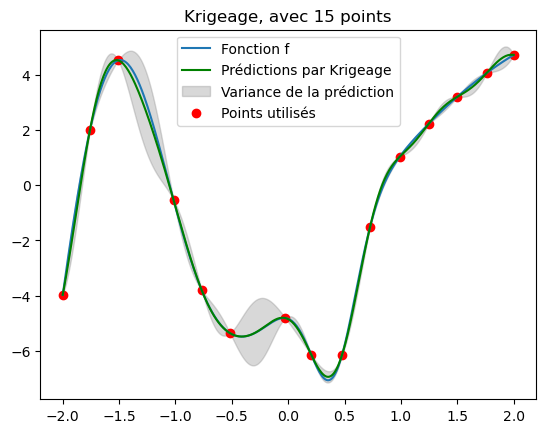

In [64]:
display_heuristic(historic_4)

Comme prévu, avec un budget de calcul inférieur, nous sommes capables de faire mieux.

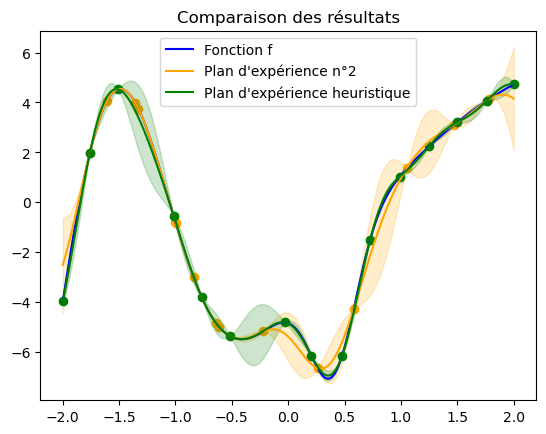

Avec  plan n°1  : 
 - moyenne :  0.2243381110162369
 - minimum :  -0.0
 - maximum :  1.0236716641560124
 - Variance totale (somme) :  89.73524440649476


Avec  plan heuristique  : 
 - moyenne :  0.1636260705339445
 - minimum :  -0.0
 - maximum :  0.7161311066120583
 - Variance totale (somme) :  65.45042821357781




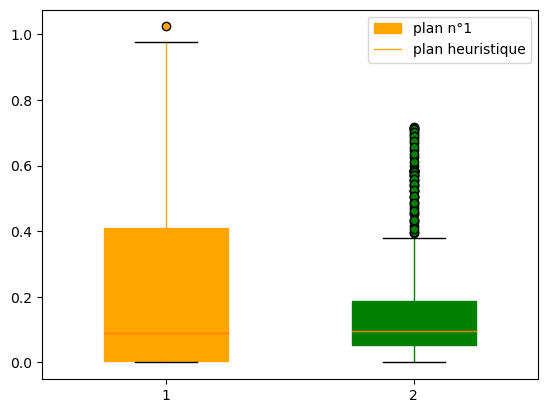

Plan d'expérience n°2 :
  - Nombre de points :  16
  - Variance cumulée :  89.735

Plan d'expérience heuristique :
  - Nombre de points :  15  (- 6.25 %)
  - Variance cumulée :  65.45  (- 27.063 %)


In [67]:
compare(pXp2,historic_4[-1][0],"Plan d'expérience n°2","Plan d'expérience heuristique")

var_comparison(pXp2,historic_4,"plan heuristique", "plan n°1")

sigma_f = historic_4[-1][3]

print("Plan d'expérience n°2 :")
print("  - Nombre de points : ",len(pXp2))
print("  - Variance cumulée : ",np.round(np.sum(sigma_pXp2),3))
print("")
print("Plan d'expérience heuristique :")
print("  - Nombre de points : ",len(historic_4[-1][0])," (-",np.round(np.abs(len(historic_4[-1][0])/len(pXp2) - 1)*100,2),"%)")
print("  - Variance cumulée : ",np.round(np.sum(sigma_f),3)," (-",np.round(abs(np.sum(sigma_f)/np.sum(sigma_pXp2)-1)*100,3),"%)")

Comme nous pouvons le voir, il est en effet possible de faire mieux, pour un budget de calcul plus petit, puisque nous diminuons ici la variance cumulée de 27%, tout en ayant un budget de calcul diminué de 6% environ.

Toutefois, nous pourrions aussi trouver un plan d'expérience ayant une variance cumulée légèrement plus grande, et un budget de calcul encore plus petit. C'est ce que nous allons regarder, en affichant les propriétés des plans de taille inférieure obtenus lors de la recherche heuristique.

In [73]:
sigma_f_1 = historic_4[-1][3]
sigma_f_2 = historic_4[-2][3]
sigma_f_3 = historic_4[-3][3]

print("Plan d'expérience n°2 :")
print("  - Nombre de points : ",len(pXp2))
print("  - Variance cumulée : ",np.round(np.sum(sigma_pXp2),3))
print("")
print("Plan d'expérience heuristique 1 :")
print("  - Nombre de points : ",len(historic_4[-1][0])," (-",np.round(np.abs(len(historic_4[-1][0])/len(pXp2) - 1)*100,2),"%)")
print("  - Variance cumulée : ",np.round(np.sum(sigma_f_1),3)," (-",np.round(abs(np.sum(sigma_f_1)/np.sum(sigma_pXp2)-1)*100,3),"%)")
print("")
print("Plan d'expérience heuristique 2 :")
print("  - Nombre de points : ",len(historic_4[-2][0])," (-",np.round(np.abs(len(historic_4[-2][0])/len(pXp2) - 1)*100,2),"%)")
print("  - Variance cumulée : ",np.round(np.sum(sigma_f_2),3)," (+",np.round(abs(np.sum(sigma_f_2)/np.sum(sigma_pXp2)-1)*100,3),"%)")
print("")
print("Plan d'expérience heuristique 3 :")
print("  - Nombre de points : ",len(historic_4[-3][0])," (-",np.round(np.abs(len(historic_4[-3][0])/len(pXp2) - 1)*100,2),"%)")
print("  - Variance cumulée : ",np.round(np.sum(sigma_f_3),3)," (+",np.round(abs(np.sum(sigma_f_3)/np.sum(sigma_pXp2)-1)*100,3),"%)")

Plan d'expérience n°2 :
  - Nombre de points :  16
  - Variance cumulée :  89.735

Plan d'expérience heuristique 1 :
  - Nombre de points :  15  (- 6.25 %)
  - Variance cumulée :  65.45  (- 27.063 %)

Plan d'expérience heuristique 2 :
  - Nombre de points :  14  (- 12.5 %)
  - Variance cumulée :  93.832  (+ 4.565 %)

Plan d'expérience heuristique 3 :
  - Nombre de points :  13  (- 18.75 %)
  - Variance cumulée :  144.337  (+ 60.848 %)


Comme nous l'espérions, l'avant dernier plan propose un compromis plutôt bon : celui-ci augmente la variance cumulée de 4% seulement, pour un gain de plus de 12% sur le budget de calcul.

# Conclusion

En conclusion, ce TP a été l'occasion pour nous de revoir, et approfondir nos connaissances sur le Krigeage, apprises en cours. Via une application assez simple, nous avons pu mettre en pratique les équations théoriques du Krigeage simple, permettant une illustration certaine de ces notions. En comparant plusieurs plans d'expériences, nous avons pu observer la dualité coût - variance, qui est centrale dans le choix d'un plan d'expérience en pratique.

Ainsi, après toutes ces analyses et comparaisons, le choix du meilleur plan d'expérience dépendra principalement des conditions qui encadrent l'estimation. En effet, si l'accent est plutôt mis sur le budget de calcul, nous souhaiterions plutôt utiliser le plan qui minimise le budget, et qui a la variance cumulée la plus petite possible (dans notre cas, le plan n°1). Si toutefois le budget alloué est plus important, il serait intéressant d'explorer un plan de budget supérieur, avec une variance diminuée (plan de taille allant de 14 à 16 points par exemple).

Bien entendu, ce compromis entre coût-variance pourrait tout aussi bien être trouvé via une optimisation d'un score, prenant en compte le budget de calcul et la variance de la prédictions, et ce, selon les contraintes de la simulation.